In [1]:
import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v4 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results import * 

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [2]:
colorgrad = "twilight"

# 1. Read Data

In [3]:
folder_data = 'data/mc_maze3'
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
dset_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))

In [4]:
# corresponding meta data
train_meta = np.load(folder_data + "/meta_train.npy", allow_pickle=True).tolist()
trial_idx_use = np.array(train_meta['trial_info']['trial_version']) == 0
np.sum(trial_idx_use)

592

# 2. Behavior Data

In [5]:
trial_type_use = np.array(train_meta['trial_info']['trial_type'])[trial_idx_use]
indices = np.where(trial_idx_use)[0]

target_pos_sel = [train_meta['trial_info']['target_pos'][idx] for idx in indices]
target_pos_sel = np.array(target_pos_sel).squeeze(1).astype(np.float32)

hand_pos_sel = [train_meta['behavior']['hand_pos'][idx] for idx in indices]
cursor_pos_sel = [train_meta['behavior']['cursor_pos'][idx] for idx in indices]
eye_pos_sel = [train_meta['behavior']['eye_pos'][idx] for idx in indices]

In [6]:
# np.save(folder_data + "/cov_static_samples.npy", target_pos_sel)

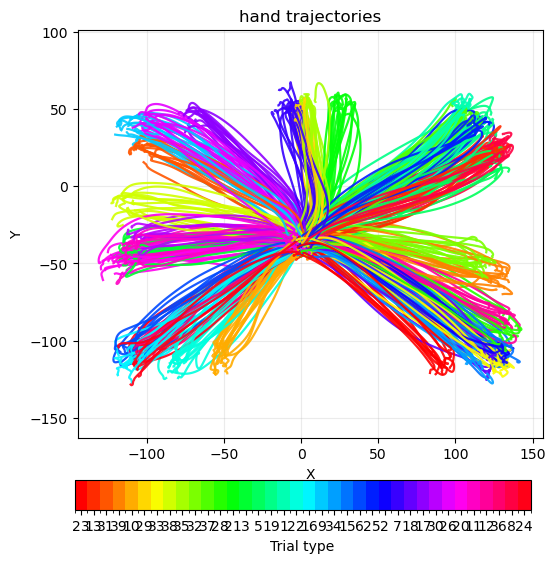

In [7]:
plot_2d_hand_trajectories(hand_pos_sel,
                          trial_indices=None,
                          trial_type_use=trial_type_use,
                          title = "hand trajectories")

In [8]:
x = target_pos_sel[:, 0]
y = target_pos_sel[:, 1]
r = np.hypot(x, y)
theta = np.arctan2(x, y)              # <-- note: x first, y second (swapped)
theta = (theta + np.pi) % (2*np.pi) - np.pi
theta[np.isclose(theta, np.pi)] = 0.0
theta_deg = np.degrees(theta)

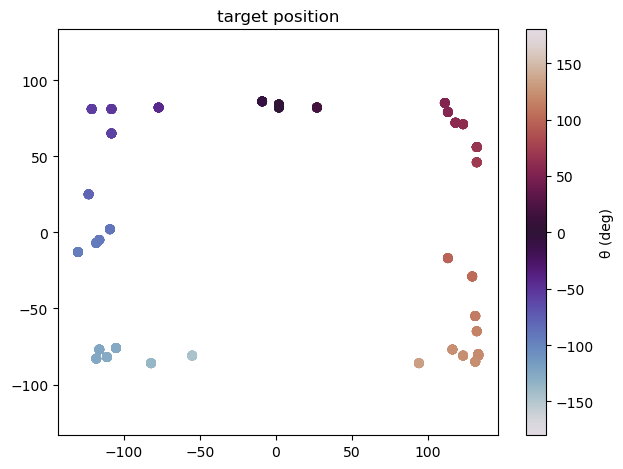

In [9]:
theta_wrapped = (theta_deg + 180) % 360 - 180
norm = colors.Normalize(vmin=-180, vmax=180)  # -180→0.0 and 180→1.0 (same color on cyclic cmaps)
plt.scatter(
    target_pos_sel[:, 0], target_pos_sel[:, 1],
    c=theta_wrapped, cmap=colorgrad, norm=norm
)
plt.title('target position')
cbar = plt.colorbar()
cbar.set_label('θ (deg)')
plt.axis('equal'); plt.tight_layout()

# 3. Brute-force PCA

In [10]:
mean, components, explained_var, explained_var_ratio, transform = pca_stream(dset_samples, n_components=None)

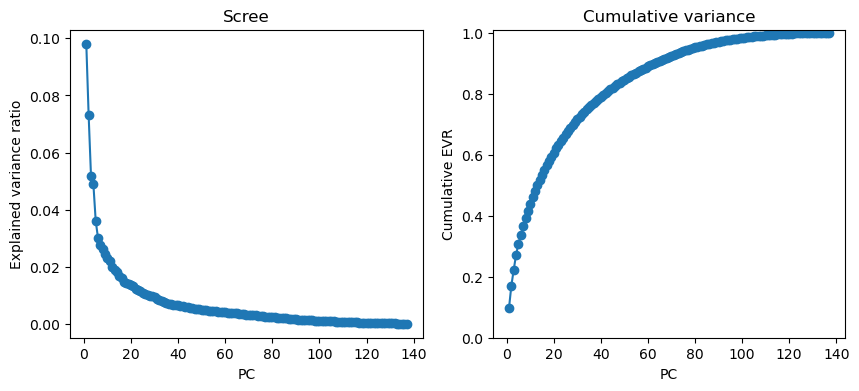

In [11]:
plot_scree(explained_var, explained_var_ratio)

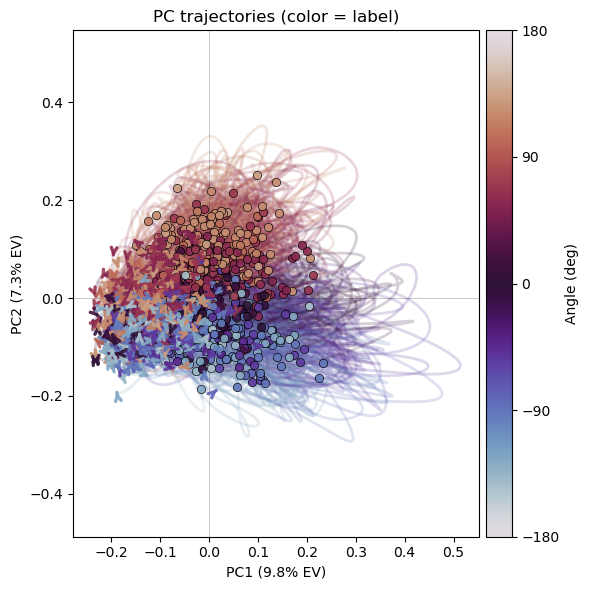

In [12]:
plot_trial_trajectories_gradient_steps(
    transform,
    dset_samples,
    trial_indices=np.arange(len(dset_samples)),   # or any subset
    comps=(0, 1),
    evr=explained_var_ratio,
    linewidth=2.0,
    start_marker_size=36,
    alpha=0.2,
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    fig_w = 6, fig_h = 6,
    labels = theta_deg,
    circmap=colorgrad
)

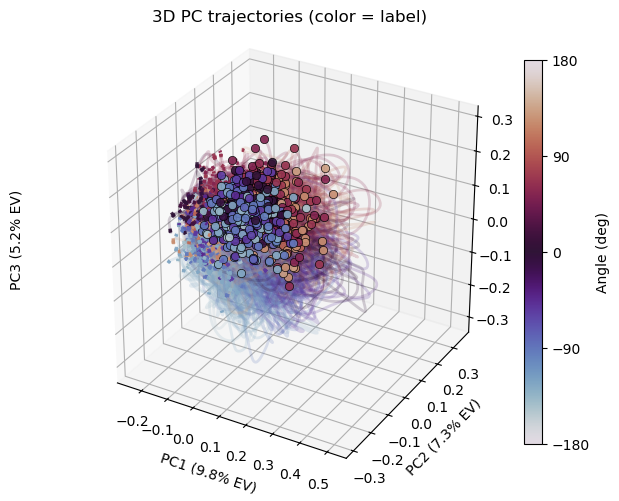

In [13]:
plot_trial_trajectories_gradient_steps_3d(
    transform,
    dset_samples,
    trial_indices=np.arange(len(dset_samples)),  # or choose a subset
    comps=(0, 1, 2),
    evr=explained_var_ratio,
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    alpha = 0.2,
    labels = theta_deg,
    circmap=colorgrad
)

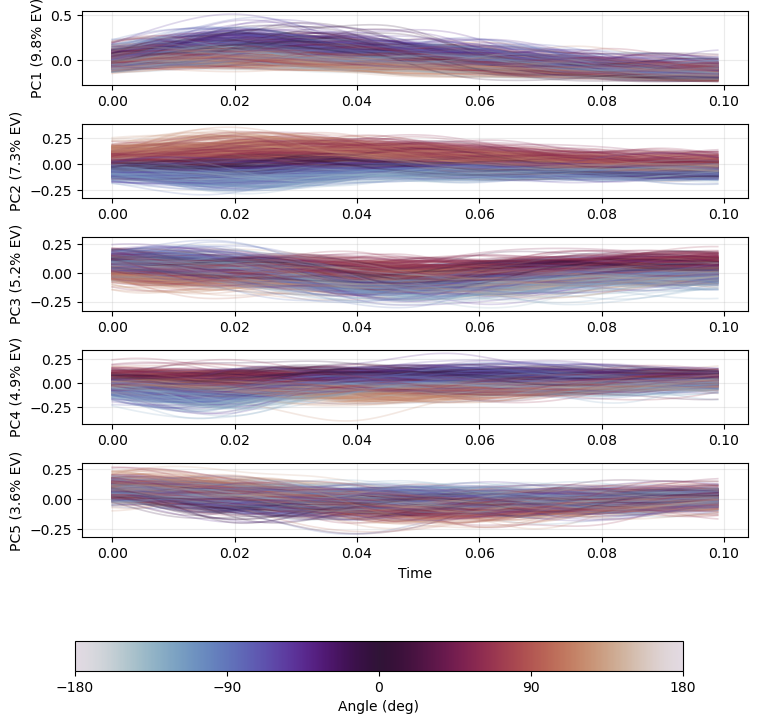

In [18]:
plot_pc_time_series(
    transform, dset_samples,
    pcs=np.arange(5),
    trial_indices=np.arange(len(dset_samples)),
    labels= theta_deg,      # trial_type_use
    evr=explained_var_ratio,
    dt=0.001, # can be None
    alpha = 0.2,
    fig_w= 8,
    fig_h_per = 1.5,
    circmap = colorgrad
)

# 3. New results

1. latent dimension = 3
2. lag = 5

No other covariates

In [19]:
dt = 0.001
folder_data = 'out/maze/dim3_lag5/data'
folder = 'out/maze/dim3_lag5/00002-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
pkl_path = folder + '/network-snapshot-500000.pkl'
dim_preserve = 3

## 3.1 Read Data & Model

In [20]:
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
lagRead_samples = np.load(folder_data + "/lag_cov_list.npz", allow_pickle=True)

In [21]:
data_raw = dataset_samples['samples']
lag_raw = lagRead_samples['samples']

dset_samples = []
lag_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))
    lag_samples.append(np.asarray(lag_raw[ii], dtype=np.float64))

In [22]:
lag = lag_samples[0].shape[1] // dset_samples[0].shape[1] - 1
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

In [23]:
clamp_range = None

In [24]:
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)
if 'ema' in model_all: net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else: net = model_all['net']  # Raw trained model
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

## 3.2 generated trajectories

### data space (tau = 1.0)

In [25]:
traj_sim_tau1, lag_cov_list = generate_traj(dyn_net.to(device), dset_samples,
                                            n_step = T_max, tau = 1.0,
                                            lag_samples = lag_samples, device = device, lag = lag,
                                            include_x0_tau = False,
                                            oracle = False, lag_cov_list_pre = None,
                                            clamp_range = clamp_range)

100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 151.97it/s]


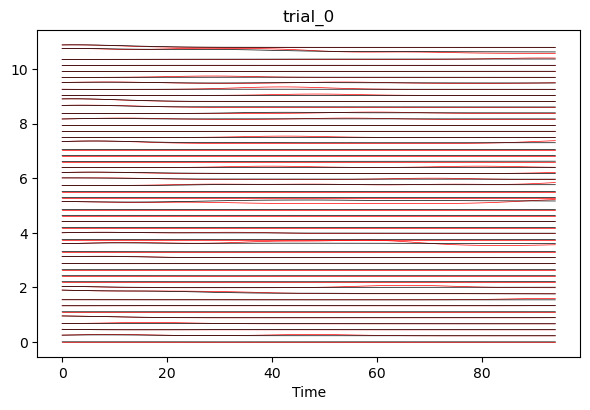

In [27]:
trial_plot = 0
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau1[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

### latnet space (tau = 0.0)

In [28]:
traj_sim_tau0, _ = generate_traj(dyn_net.to(device), dset_samples,
                                 n_step = T_max, tau = 0.0,
                                 lag_samples = lag_samples, device = device, lag = lag,
                                 include_x0_tau = False,
                                 oracle = False, lag_cov_list_pre = lag_cov_list,
                                 flow_net = flow_net.to(device), clamp_range = clamp_range)

project starting points to latent


100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 188.60it/s]


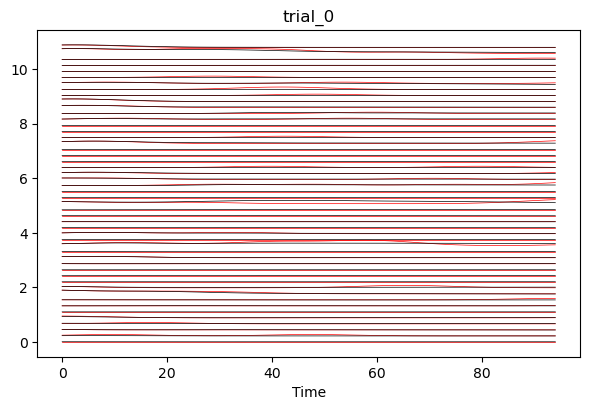

In [30]:
trial_plot = 0
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau0[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

## 3.3 Latent trajectories

### 3.3.1 simulated latent trajectories

In [31]:
mu_traj = latent_mu(traj_sim_tau0, encoder, dim_preserve, device)

100%|███████████████████████████████████████| 592/592 [00:00<00:00, 3616.38it/s]


/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.18 if use_labels else 0.02, 0.98, 0.98])


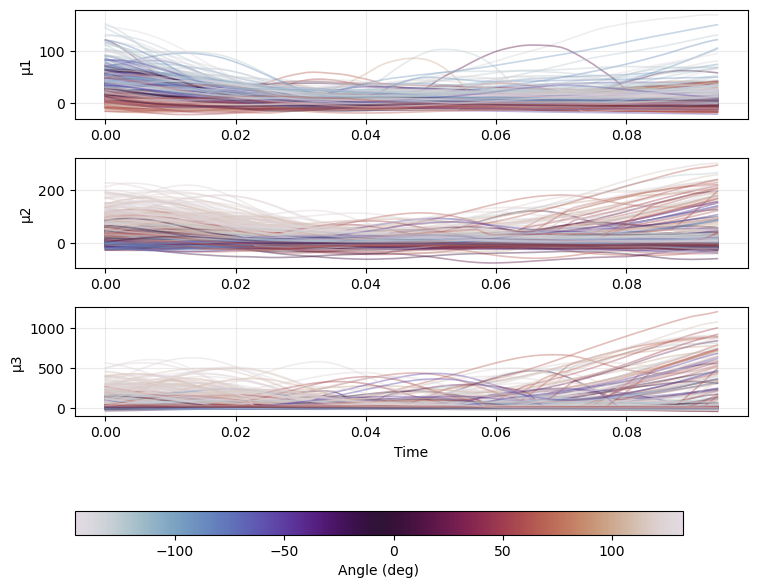

In [32]:
mu_traj_np = [mu_traj[j].cpu().numpy() for j in range(len(mu_traj))]
plot_latent_time_series(mu_traj_np, alpha = 0.4, dims=np.arange(dim_preserve),
                        dt=dt, labels=theta_deg)

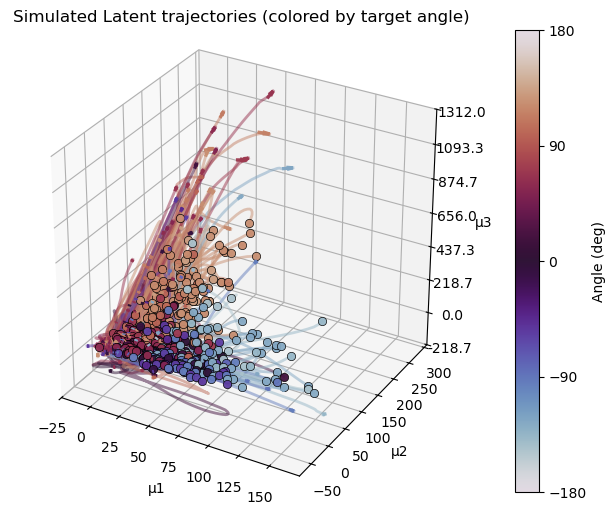

In [33]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Simulated Latent trajectories (colored by target angle)",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = None, # (20,45)
)

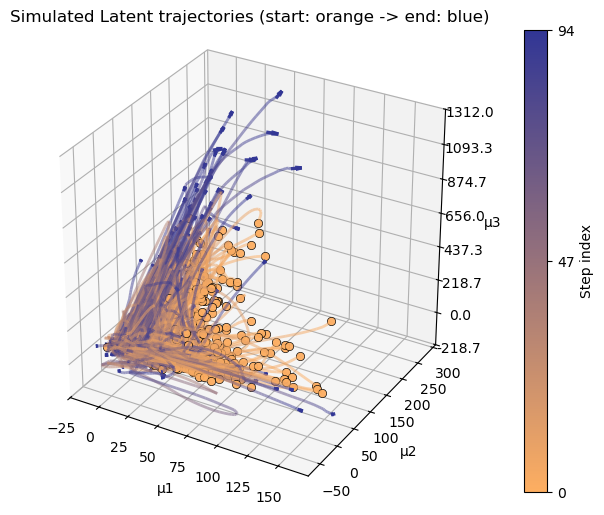

In [34]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np, 
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Simulated Latent trajectories (start: orange -> end: blue)",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    elev_azim = None, # (20,45)
)

### 3.3.2 Flow data to latent space

In [35]:
latent_traj_list = proj_to_latent(dset_samples, flow_net, 0.0, device)

100%|████████████████████████████████████████| 592/592 [00:04<00:00, 141.61it/s]


100%|███████████████████████████████████████| 592/592 [00:00<00:00, 3577.99it/s]
/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.18 if use_labels else 0.02, 0.98, 0.98])


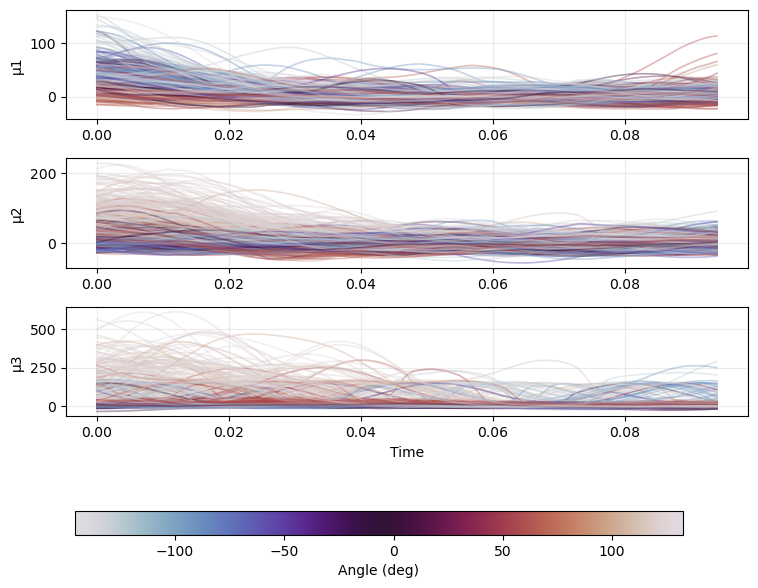

In [36]:
mu_traj = latent_mu(latent_traj_list, encoder, dim_preserve, device)
mu_traj_np = [mu_traj[j].cpu().numpy() for j in range(len(mu_traj))]
plot_latent_time_series(mu_traj_np, alpha = 0.4, dims=np.arange(dim_preserve),
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)

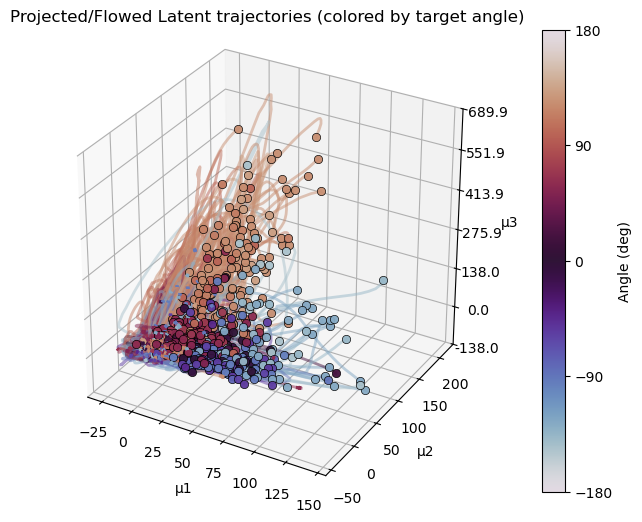

In [37]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Projected/Flowed Latent trajectories (colored by target angle)",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = None, # (20,45)
)

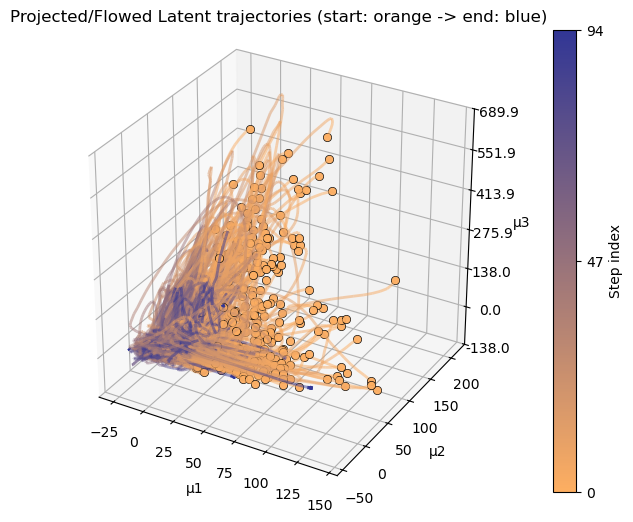

In [38]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np, 
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Projected/Flowed Latent trajectories (start: orange -> end: blue)",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    elev_azim = None, # (20,45)
)

# 4. Another Run...

In [39]:
folder = 'out/maze/dim3_lag5/00003-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
pkl_path = folder + '/network-snapshot-500000.pkl'

In [40]:
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)
if 'ema' in model_all: net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else: net = model_all['net']  # Raw trained model
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

## 4.1 genearted trajectories

### data space (tau = 1.0)

In [41]:
traj_sim_tau1, lag_cov_list = generate_traj(dyn_net.to(device), dset_samples,
                                            n_step = T_max, tau = 1.0,
                                            lag_samples = lag_samples, device = device, lag = lag,
                                            include_x0_tau = False,
                                            oracle = False, lag_cov_list_pre = None,
                                            clamp_range = clamp_range)

100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 186.11it/s]


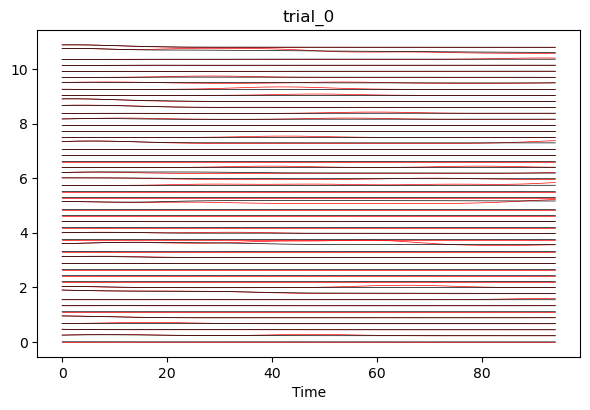

In [42]:
trial_plot = 0
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau1[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

### latent space (tau = 0.0)

In [43]:
traj_sim_tau0, _ = generate_traj(dyn_net.to(device), dset_samples,
                                 n_step = T_max, tau = 0.0,
                                 lag_samples = lag_samples, device = device, lag = lag,
                                 include_x0_tau = False,
                                 oracle = False, lag_cov_list_pre = lag_cov_list,
                                 flow_net = flow_net.to(device), clamp_range = clamp_range)

project starting points to latent


100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 190.60it/s]


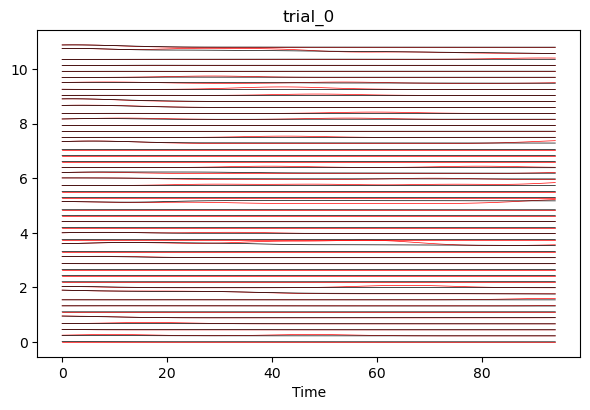

In [44]:
trial_plot = 0
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau0[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

### 3.3 latent trajectories

### 3.3.1 simulated latent trajectories

In [45]:
mu_traj = latent_mu(traj_sim_tau0, encoder, dim_preserve, device)

100%|███████████████████████████████████████| 592/592 [00:00<00:00, 3630.07it/s]


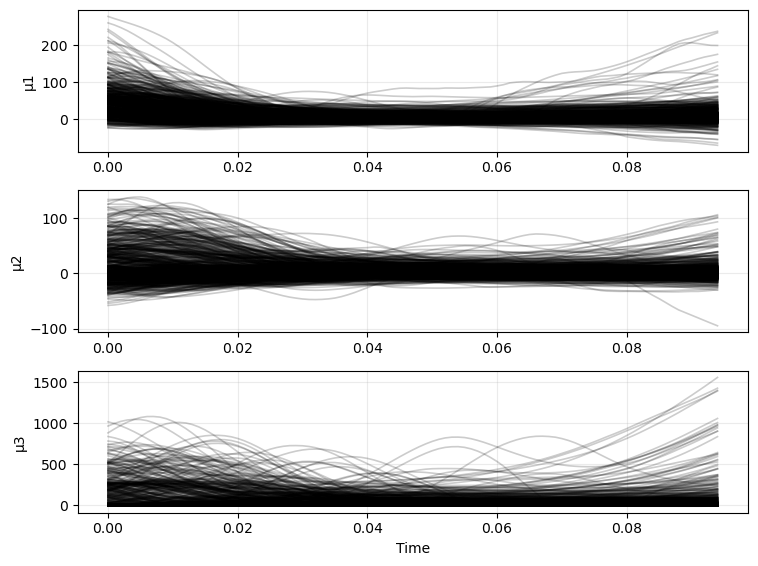

In [46]:
mu_traj_np = [mu_traj[j].cpu().numpy() for j in range(len(mu_traj))]
plot_latent_time_series(mu_traj_np, alpha = 0.2, dims=np.arange(dim_preserve),
                        dt=dt, labels=None)

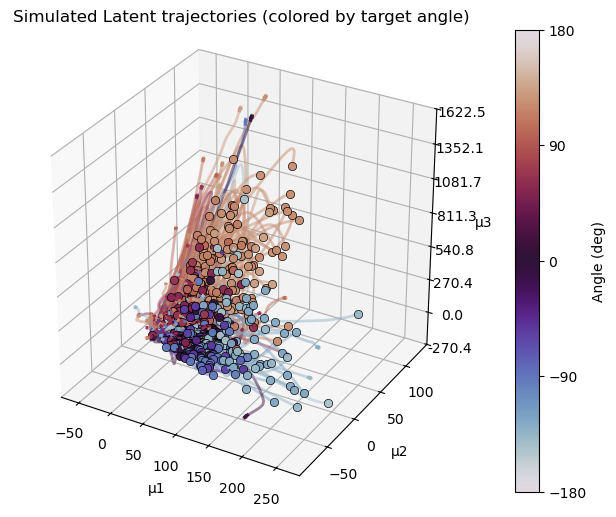

In [47]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Simulated Latent trajectories (colored by target angle)",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = None, # (20,45)
)

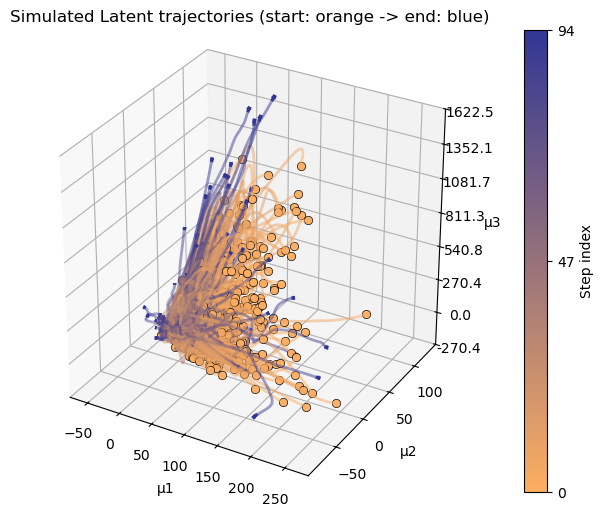

In [48]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np, 
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Simulated Latent trajectories (start: orange -> end: blue)",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    elev_azim = None, # (20,45)
)

### 3.3.2 flow data to latent trajectories

In [49]:
latent_traj_list = proj_to_latent(dset_samples, flow_net, 0.0, device)

100%|████████████████████████████████████████| 592/592 [00:04<00:00, 140.22it/s]


100%|███████████████████████████████████████| 592/592 [00:00<00:00, 3591.00it/s]
/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.18 if use_labels else 0.02, 0.98, 0.98])


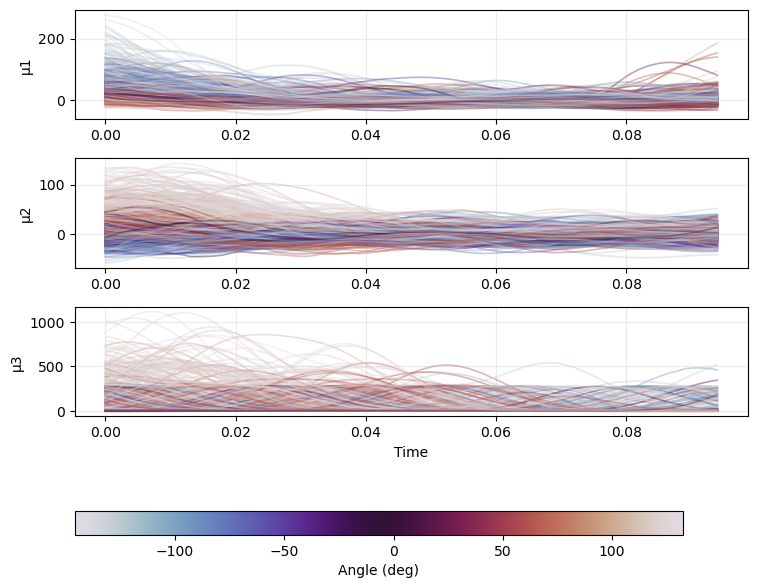

In [50]:
mu_traj = latent_mu(latent_traj_list, encoder, dim_preserve, device)
mu_traj_np = [mu_traj[j].cpu().numpy() for j in range(len(mu_traj))]
plot_latent_time_series(mu_traj_np, alpha = 0.4, dims=np.arange(dim_preserve),
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)

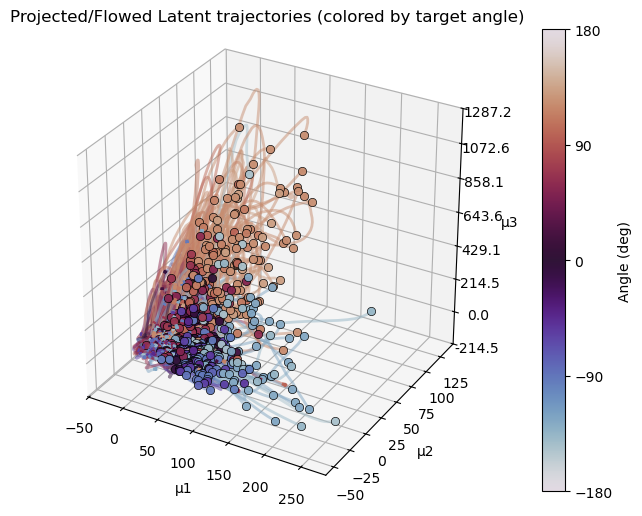

In [51]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Projected/Flowed Latent trajectories (colored by target angle)",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = None, # (20,45)
)

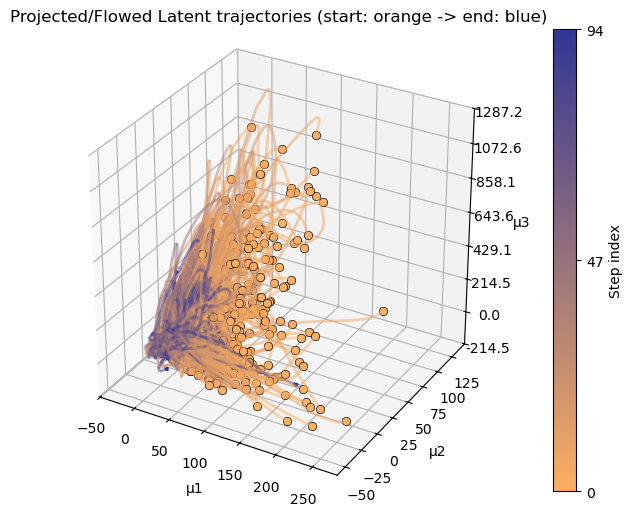

In [52]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np, 
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Projected/Flowed Latent trajectories (start: orange -> end: blue)",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    elev_azim = None, # (20,45)
)